---

# MEMORY USAGE & DATA TYPES

---

DataFrames are stored entirely in memory, so **memory optimization** is key in working with large datasets in Pandas.

Memory Optimization Best Practices (*in order*):

    1. Drop unnecessary columns (*when possible, avoid reading them in at all*)
    2. Convert `object` types to `numeric` or `datetime` datatypes where possible
    3. Downcast numeric data to the smallest appropiate bit size
    4. Use the categorical datatype for columns where the number of unique values < rows / 2

---

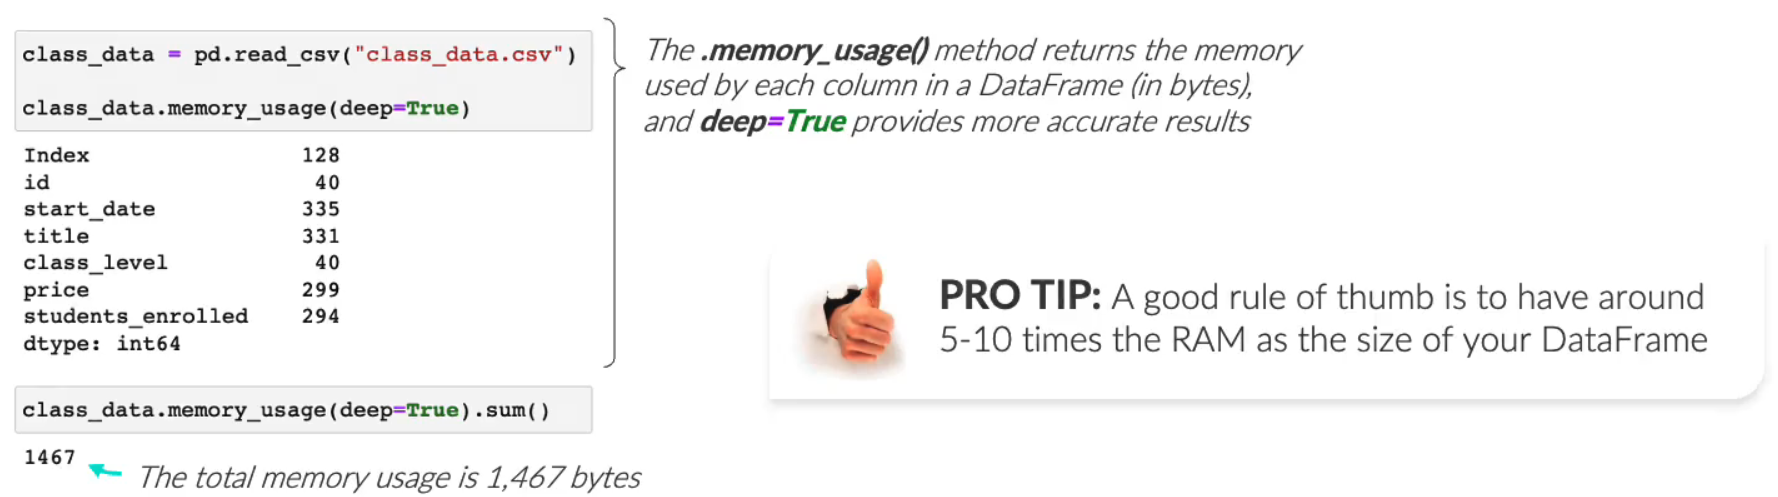

---

In [1]:
import numpy as np
import pandas as pd

In [2]:
retail = pd.read_csv('Data/retail_2016_2017.csv')
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054944 entries, 0 to 1054943
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   id           1054944 non-null  int64  
 1   date         1054944 non-null  object 
 2   store_nbr    1054944 non-null  int64  
 3   family       1054944 non-null  object 
 4   sales        1054944 non-null  float64
 5   onpromotion  1054944 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 48.3+ MB


In [3]:
retail.memory_usage(deep=True)

Index               132
id              8439552
date           62241696
store_nbr       8439552
family         63040896
sales           8439552
onpromotion     8439552
dtype: int64

In [4]:
total_memory = retail.memory_usage(deep=True).sum()

print(f'Total memory usage on retail DataFrames is: {total_memory/1e6:.3f} MB')

Total memory usage on retail DataFrames is: 159.041 MB


<br><br>

---


## STEP 1: Drop Columns

**Dropping unnecessary columns** is an easy way to free up significant space

    - You may not know which columns are important when reading in a dataset for the first time.
    - If you do, you can limit the columns you read in to begin with (more on that later!)

In [5]:
retail_step1 = retail.copy()
retail_step1.head()

,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.0,0
1,1945945,2016-01-01,1,BABY CARE,0.0,0
2,1945946,2016-01-01,1,BEAUTY,0.0,0
3,1945947,2016-01-01,1,BEVERAGES,0.0,0
4,1945948,2016-01-01,1,BOOKS,0.0,0


In [6]:
retail_step1.memory_usage(deep=True).sum()/1e6

np.float64(159.040932)

In [7]:
# Let's suppose that the "ID" column is not a necessary column for you project. So let's drop it
retail_step1.drop(labels='id', axis=1, inplace=True)

# Now let's see the memory saved
retail_step1.memory_usage(deep=True).sum()/1e6

np.float64(150.60138)

<br><br>

---


## STEP 2: Converting Object Data Types

Try to **convert `object` data types** to `numeric` or `datetime` whenever possible:


In [8]:
retail_step2 = retail.copy()

In [9]:
retail_step2.sample(5)

,id,date,store_nbr,family,sales,onpromotion
467689,2413633,2016-09-19,31,GROCERY II,17.0,0
836388,2782332,2017-04-15,27,BEVERAGES,3750.0,30
650665,2596609,2017-01-01,16,BOOKS,0.0,0
758251,2704195,2017-03-02,34,EGGS,228.0,4
998857,2944801,2017-07-15,35,GROCERY II,2.0,0


In [10]:
retail_step2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054944 entries, 0 to 1054943
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   id           1054944 non-null  int64  
 1   date         1054944 non-null  object 
 2   store_nbr    1054944 non-null  int64  
 3   family       1054944 non-null  object 
 4   sales        1054944 non-null  float64
 5   onpromotion  1054944 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 48.3+ MB


In [11]:
retail_step2 =retail_step2.astype({'date':'datetime64[ns]', 'family':'string',})

# Let's see the improved result
retail_step2.memory_usage(deep=True).sum() / 1e6

np.float64(105.238788)

In [12]:
retail_step2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054944 entries, 0 to 1054943
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   id           1054944 non-null  int64         
 1   date         1054944 non-null  datetime64[ns]
 2   store_nbr    1054944 non-null  int64         
 3   family       1054944 non-null  string        
 4   sales        1054944 non-null  float64       
 5   onpromotion  1054944 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), string(1)
memory usage: 48.3 MB


<br><br>

---


## STEP 3: Downcast Numeric Data

Integers and Floats are cast as **64-bit** by default to handle any possible value, buy you can **downcast numeric data** to a smaller bit size to save space if possible:

    - `8-bits` = -128 to 127
    - `16-bits` = -32'768 to 32'767
    - `32-bits` = -2'147'483'648 to 2'147'483'647
    - `64-bits` = -9'223'372'036'854'775'808 to 9'223'372'036'854'775'807


In [13]:
retail_step3 = retail.copy()
retail_step3.sample(5)

,id,date,store_nbr,family,sales,onpromotion
749128,2695072,2017-02-25,28,POULTRY,311.203,1
764089,2710033,2017-03-05,48,CLEANING,4608.000,12
393415,2339359,2016-08-08,47,"LIQUOR,WINE,BEER",178.000,0
1023013,2968957,2017-07-29,13,GROCERY II,28.000,0
310055,2255999,2016-06-22,9,LAWN AND GARDEN,2.000,0


In [14]:
retail_step3.id.unique()

array([1945944, 1945945, 1945946, ..., 3000885, 3000886, 3000887],
      shape=(1054944,))

In [15]:
retail_step3.store_nbr.unique() # we can use 8-bit Int

array([ 1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,  2, 20, 21, 22, 23, 24,
       25, 26, 27, 28, 29,  3, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,  4,
       40, 41, 42, 43, 44, 45, 46, 47, 48, 49,  5, 50, 51, 52, 53, 54,  6,
        7,  8,  9])

In [16]:
retail_step3.onpromotion.unique() # we can use 16-bit Int

array([  0,   1,  11,  47,  24,   4,  41,  27,   2,   7,   3,  15,  22,
        18,   6,  20,   5,  13,  16,  12,  19,   9,  28,   8,  25,  23,
        10,  14,  17,  21,  26,  30,  67,  39,  35,  29,  31,  45,  74,
        33,  69,  71,  36,  75,  62,  72,  77,  40,  37,  70,  58, 132,
        81,  42,  85,  99, 135, 116, 124, 107, 129,  80, 125, 110, 120,
       152, 101,  84, 145, 216,  61,  93,  83, 112,  66, 209, 114, 109,
       187, 207, 148, 200, 119,  68,  57,  82, 111,  50, 195, 164, 108,
       180,  96, 168, 192,  73, 212, 197, 193, 233, 169, 220, 185, 172,
       178, 215, 226, 130,  43,  46,  55,  48,  56,  49,  65,  44,  54,
        52,  38,  59,  51,  32,  64,  53,  34,  78,  60,  90, 133,  79,
       100, 127, 103, 123, 106, 142,  98, 208, 118, 203,  97, 205, 171,
       183, 170, 204, 210, 211, 230, 175, 221, 166, 223, 122,  76, 137,
       121, 126, 113, 155, 104, 140,  86,  89, 214, 150, 201, 213, 199,
       173,  95, 222, 217, 194, 231, 229,  63,  88, 136, 128, 10

In [17]:
print(retail_step3.sales.unique())
print(retail_step3.sales.min())
print(retail_step3.sales.max())

[   0.       4.      13.    ...  438.133  154.553 2419.729]
0.0
124717.0


In [18]:
retail_step3 = retail_step3.astype({'id':'int32', 'store_nbr':'int8', 'sales':'float32', 'onpromotion':'int16'}, copy=True)

retail_step3.memory_usage(deep=True).sum() / 1e6

np.float64(136.887108)

In [19]:
retail_step3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054944 entries, 0 to 1054943
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   id           1054944 non-null  int32  
 1   date         1054944 non-null  object 
 2   store_nbr    1054944 non-null  int8   
 3   family       1054944 non-null  object 
 4   sales        1054944 non-null  float32
 5   onpromotion  1054944 non-null  int16  
dtypes: float32(1), int16(1), int32(1), int8(1), object(2)
memory usage: 27.2+ MB


<br><br>

---


## STEP 4: Using the Categorical Data Type

**Use the `categorical` data type** if you have string columns where the number of unique values is less than half of the total number or rows

    

In [20]:
retail_step4 = retail.copy()

print(retail_step4.memory_usage(deep=True).sum()/1e6, '\n')
retail_step4.info()

159.040932 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054944 entries, 0 to 1054943
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   id           1054944 non-null  int64  
 1   date         1054944 non-null  object 
 2   store_nbr    1054944 non-null  int64  
 3   family       1054944 non-null  object 
 4   sales        1054944 non-null  float64
 5   onpromotion  1054944 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 48.3+ MB


In [21]:
print(retail_step4.family.unique())

retail_step4.family.nunique()

['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


33

In [22]:
retail_step4.family = retail_step4.family.astype('category')

print(retail_step4.memory_usage(deep=True).sum()/1e6, '\n')
retail_step4.info(memory_usage='deep')

97.058024 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054944 entries, 0 to 1054943
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype   
---  ------       --------------    -----   
 0   id           1054944 non-null  int64   
 1   date         1054944 non-null  object  
 2   store_nbr    1054944 non-null  int64   
 3   family       1054944 non-null  category
 4   sales        1054944 non-null  float64 
 5   onpromotion  1054944 non-null  int64   
dtypes: category(1), float64(1), int64(3), object(1)
memory usage: 92.6 MB


---

# OVERALL MEMORY OPTIMIZATION

---

In [23]:
retail.head()

,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.0,0
1,1945945,2016-01-01,1,BABY CARE,0.0,0
2,1945946,2016-01-01,1,BEAUTY,0.0,0
3,1945947,2016-01-01,1,BEVERAGES,0.0,0
4,1945948,2016-01-01,1,BOOKS,0.0,0


In [24]:
retail.memory_usage(deep=True).sum() / 1e6

np.float64(159.040932)

In [25]:
retail = retail.astype({'id':'int32', 'date':'datetime64[ns]', 'store_nbr':'int8', 'family':'category', 'sales':'float32', 'onpromotion':'int16'})

retail.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054944 entries, 0 to 1054943
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   id           1054944 non-null  int32         
 1   date         1054944 non-null  datetime64[ns]
 2   store_nbr    1054944 non-null  int8          
 3   family       1054944 non-null  category      
 4   sales        1054944 non-null  float32       
 5   onpromotion  1054944 non-null  int16         
dtypes: category(1), datetime64[ns](1), float32(1), int16(1), int32(1), int8(1)
memory usage: 20.1 MB


In [26]:
retail.memory_usage(deep=True).sum() / 1e6

np.float64(21.102056)

In [27]:
print(f'Final size of the dataset: {21.102/159.04*100:.2f}% from the origianl size')

Final size of the dataset: 13.27% from the origianl size


<br><br><br>

---

## A Note on Efficiency

**Premature optimization is the root of all evil** - Don Knuth

>1. Data Analysis is an **iterative process**
>    - It's normal not to know the best version of a dataset from the beginning
>    - Once you understand the data and have an analysis path, then you can optimize.

>2. Efficiency's importance **depends on the use case**
>    - If all you need is a quick analysis, fully optimazing your code will often only waste time
>    - If you are building a `pipeline that will run frequently`, optimization is critical

>3. Build **efficient habits & workflows**
>    - As you work more with Python and Pandas, take time to review your code and note areas of improvement - you'll be able to incorporate better practices next time!

---

<br><br>

---

# ASSIGNMENT: MEMORY OPTIMIZATION

---

In [28]:
transactions = pd.read_csv('Data/transactions.csv')
transactions.columns = ['date', 'store_number', 'transactions_count']
transactions.head()

,date,store_number,transactions_count
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [29]:
conditions = [
    (transactions['date'].astype('datetime64[ns]').dt.month == 12),
    (transactions['date'].astype('datetime64[ns]').dt.month == 5) & (transactions['date'].astype('datetime64[ns]').dt.dayofweek == 6),
    (transactions['date'].astype('datetime64[ns]').dt.month == 7) & (transactions['date'].astype('datetime64[ns]').dt.day_of_week == 0)
]

choices = ['Holiday Bonus', 'Corporate Month', 'Summer Special']

# ---------------------------------------------------------------------------------------
transactions = transactions.assign(
    target_pct = transactions.transactions_count / 2500,
    met_target = transactions.transactions_count / 2500 >=1,
    bonus_payable = (transactions.transactions_count / 2500 >=1) * 100,
    month = transactions.date.astype('datetime64[ns]').dt.month,
    day_of_week = transactions.date.astype('datetime64[ns]').dt.dayofweek,
    seasonal_bonus = np.select(condlist=conditions, choicelist=choices, default='None')
)

transactions.head()

,date,store_number,transactions_count,target_pct,met_target,bonus_payable,month,day_of_week,seasonal_bonus
0,2013-01-01,25,770,0.3080,False,0,1,1,None
1,2013-01-02,1,2111,0.8444,False,0,1,2,None
2,2013-01-02,2,2358,0.9432,False,0,1,2,None
3,2013-01-02,3,3487,1.3948,True,100,1,2,None
4,2013-01-02,4,1922,0.7688,False,0,1,2,None


In [30]:
transactions.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                83488 non-null  object 
 1   store_number        83488 non-null  int64  
 2   transactions_count  83488 non-null  int64  
 3   target_pct          83488 non-null  float64
 4   met_target          83488 non-null  bool   
 5   bonus_payable       83488 non-null  int64  
 6   month               83488 non-null  int32  
 7   day_of_week         83488 non-null  int32  
 8   seasonal_bonus      83488 non-null  object 
dtypes: bool(1), float64(1), int32(2), int64(3), object(2)
memory usage: 12.3 MB


In [31]:
original_size = transactions.memory_usage(deep=True).sum() / 1e6
original_size

np.float64(12.851156)

In [32]:
transactions = transactions.astype({
    'date':'datetime64[ns]', 'store_number':'int8', 'transactions_count':'int16',
    'target_pct':'float32', 'bonus_payable':'int8', 'month':'int8', 
    'day_of_week':'int8', 'seasonal_bonus':'category'
    
})

transactions.head()

,date,store_number,transactions_count,target_pct,met_target,bonus_payable,month,day_of_week,seasonal_bonus
0,2013-01-01,25,770,0.3080,False,0,1,1,None
1,2013-01-02,1,2111,0.8444,False,0,1,2,None
2,2013-01-02,2,2358,0.9432,False,0,1,2,None
3,2013-01-02,3,3487,1.3948,True,100,1,2,None
4,2013-01-02,4,1922,0.7688,False,0,1,2,None


In [33]:
transactions.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                83488 non-null  datetime64[ns]
 1   store_number        83488 non-null  int8          
 2   transactions_count  83488 non-null  int16         
 3   target_pct          83488 non-null  float32       
 4   met_target          83488 non-null  bool          
 5   bonus_payable       83488 non-null  int8          
 6   month               83488 non-null  int8          
 7   day_of_week         83488 non-null  int8          
 8   seasonal_bonus      83488 non-null  category      
dtypes: bool(1), category(1), datetime64[ns](1), float32(1), int16(1), int8(4)
memory usage: 1.6 MB


In [34]:
final_size = transactions.memory_usage(deep=True).sum() / 1e6
final_size

np.float64(1.670306)

In [35]:
result = (original_size - final_size)/ original_size *100
result

np.float64(87.00267898078586)